# Simulation CLP PID FF
Import

In [147]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from matplotlib import colors as mcolors

from package_DBR import *
from package_Lab import *

Set Graph

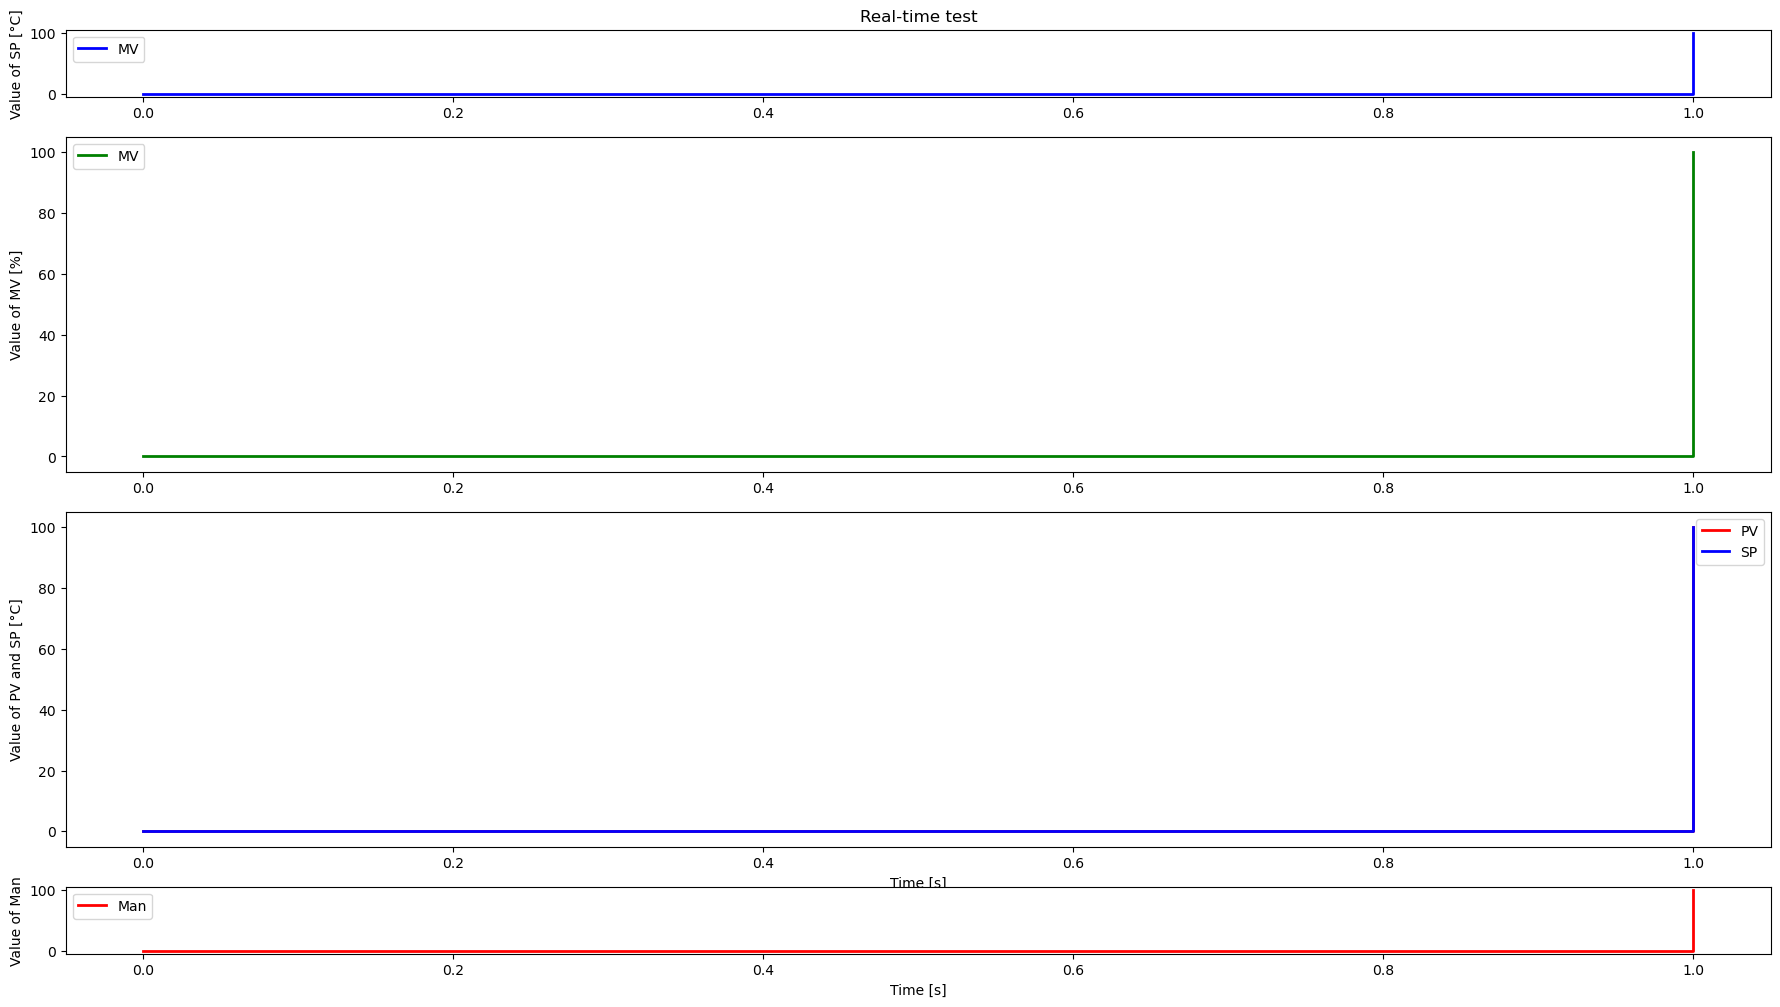

In [148]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4,1, figsize=(15,9),
                        gridspec_kw={'height_ratios': [1, 5, 5, 1]})
fig.set_figheight(12)
fig.set_figwidth(22)

l1, = ax1.step([0,1],[0,100],'b-',linewidth=2,label='MV',where='post')
ax1.set_ylabel('Value of SP [°C]')
ax1.set_title('Real-time test')
ax1.legend(loc='best')

l2, = ax2.step([0,1],[0,100],'g-',linewidth=2,label='MV',where='post')
ax2.set_ylabel('Value of MV [%]')
ax2.legend(loc='best')

l3, = ax3.step([0,1],[0,100],'r-',linewidth=2,label='PV',where='post')
l4, = ax3.step([0,1],[0,100],'b-',linewidth=2,label='SP',where='post')
ax3.set_xlabel('Time [s]')
ax3.set_ylabel('Value of PV and SP [°C]')
ax3.legend(loc='best') 

l5, = ax4.step([0,1],[0,100],'r-',linewidth=2,label='Man',where='post')
ax4.set_xlabel('Time [s]')
ax4.set_ylabel('Value of Man')
ax4.legend(loc='best') 

Set list

In [149]:
TSim = 1000
Ts = 1
N = int(TSim/Ts) + 1

# Path
SPPath = {0: 50, 500: 60,TSim: 60}
PVPath = {0: 50, TSim: 50}
DVPath = {0: 50, TSim: 50}
ManPath = {0: True,225:False, TSim:False}
MVManPath = {0: 60, 225: 0 , TSim: 0}
MVFFPath= {0:0,80:10,TSim:10}

t = []
SP = []

MV = []
MVDelay = []

DV = []
MVFFDelay = []
MVFF_FLL = []
MVFF = []

MVDelayp = []
PV1p = []
PV2p = []

MVDelayd = []
PV1d = []
PV2d = []

MVMan = []
MVP = []
MVI = []
MVD = []
PV = []
PV_P = []
PV_D = []
E = []
Man = []

# Parameters
DV0 = 50
MV0 = 50
PV0 = 50
gamma = 0.6
Kc = 0
Ti = 0
Td = 0
alpha = 1.1
MVMin = 0
MVMax = 100
ManFF = False
Kd = 0.618599605156834
Kp = 0.540610574655048
T1d = 147.5486385332903
T2d = 36.22565494631446
T1p = 130.5026136090156
T2p = 35.46518028608689
Thetap = 14.348568183245677
Thetad = 13.351904889062693

Run simulation

In [150]:

for i in range(0,N):

    t.append(i*Ts)
    SelectPath_RT(SPPath,t,SP)
    SelectPath_RT(DVPath,t,DV)
    SelectPath_RT(ManPath,t,Man)
    SelectPath_RT(MVManPath,t,MVMan)

    #MVFF
    Delay_RT(DV-DV0*np.ones_like(DV),Thetad+Thetap,Ts,MVFFDelay)
    LL_RT(MVFFDelay,Kp,Ts,T1p,T1d,MVFF_FLL)
    LL_RT(MVFF_FLL,Kp,Ts,T2p,T2d,MVFF,0)

    Kc, Ti, Td = IMC_TUNING(Kp,gamma,T1p,T2p)

    PID_RT(SP,PV,Man,MVMan,MVFF,Kc,Ti,Td,alpha,Ts,MVMin,MVMax,MV,MVP,MVI,MVD,E,ManFF)

    #P(s)
    Delay_RT(MV, Thetap, Ts, MVDelayp,MV0)
    FO_RT(MVDelayp, Kp, T1p, Ts, PV1p, 0)
    FO_RT(PV1p, 1, T2p, Ts, PV2p, 0)

    #D(s)
    Delay_RT(DV - DV0*np.ones_like(DV),Thetad,Ts,MVDelayd)
    FO_RT(MVDelayd, Kp, T1d, Ts, PV1d, 0)
    FO_RT(PV1d, 1, T2d, Ts, PV2d, 0)

    PV.append(PV2p[-1] + PV2d[-1] + PV0-Kp*MV0)

    l1.set_data(t,SP)
    l2.set_data(t,MV)
    l3.set_data(t,PV)
    l4.set_data(t,SP)
    l5.set_data(t,Man)

    clear_output(wait=True)    

    ax1.set_xlim(0, t[-1]+1)
    ax2.set_xlim(0, t[-1]+1)
    ax3.set_xlim(0, t[-1]+1)
    ax4.set_xlim(0, t[-1]+1)

    if i > 1:
        ax1.set_ylim(myRound(np.min(SP),5)-5, myRound(np.max(SP),5)+5)
        ax2.set_ylim(myRound(np.min(MV),5)-5, myRound(np.max(MV),5)+5)
        ax3.set_ylim(0, myRound(np.max(SP),5)+5)
        ax4.set_ylim(myRound(np.min(Man),5)-5, myRound(np.max(Man),5)+5) 

    display(fig)  


KeyboardInterrupt: 